In [2]:
import qutip
import matplotlib
from qutip.piqs.piqs  import *
import numpy as np
import os
import time
import gc
# Optional: set MOSEKLM_LICENSE_FILE to your local MOSEK license path if using MOSEK.
from qer.noisemodel import*
from qer.codewords import*
from qer.optimisation import*
import matplotlib.pyplot as plt

Seven-qubit code: N = 7 qubits
BGM code (3,3,1): N = 9 qubits

Processing gamma=1.00e-05

Processing gamma=2.15e-05

Processing gamma=4.64e-05

Processing gamma=1.00e-04

Processing gamma=2.15e-04

Processing gamma=4.64e-04

Processing gamma=1.00e-03

Processing gamma=2.15e-03

Processing gamma=4.64e-03

Processing gamma=1.00e-02


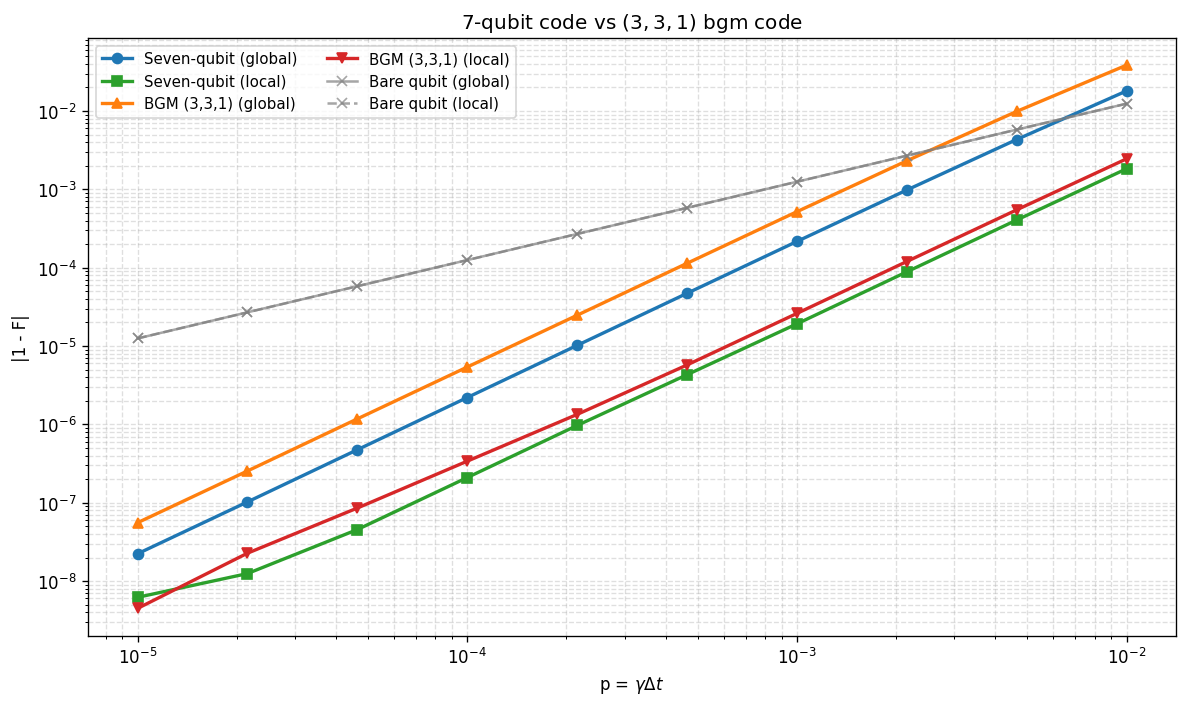


=== Fresh comparison complete ===


In [6]:
# ============================================================
# Fresh comparison: Seven-qubit vs BGM vs bare qubit
# (global + local symmetric depolarizing noise)
# ============================================================

# Code parameters
N_seven = 7
b, g_bgm, m = 3, 3, 1
N_bgm = 2*b*m + g_bgm  # N = 2*b*m + g

print(f"Seven-qubit code: N = {N_seven} qubits")
print(f"BGM code ({b},{g_bgm},{m}): N = {N_bgm} qubits")

# Simulation parameters
gamma = np.logspace(-5, -2, 10)
dt = 1
p_vals = np.array(gamma) * dt

plt.figure(figsize=(10, 6), dpi=120)

method = 'choi'

# Initialize codes
rho_seven, l0_seven, l1_seven = seven_qubit_piqs(return_qutip=True)
rho_bgm, l0_bgm, l1_bgm = bgmcode_piqs(b, g_bgm, m, return_qutip=True)

# Storage for results
results = {
    'seven_global': [], 'seven_local': [],
    'bgm_global': [], 'bgm_local': [],
    'bare_global': [], 'bare_local': []
}

# Main loop
for g in gamma:
    print(f"\nProcessing gamma={g:.2e}")
    for noise_type, key_suffix in [
        ('global symmetric depolarizing', 'global'),
        ('local symmetric depolarizing', 'local')
]:
        # Seven-qubit code
        try:
            kraus = noisemodel(noise_type, N_seven, g, dt, method)
            fid = optimise(l0_seven, l1_seven, kraus, solver='mosek')
            results[f'seven_{key_suffix}'].append(abs(1.0 - float(fid)))
        except Exception as e:
            print(f"  ERROR Seven-qubit {key_suffix}: {e}")
            results[f'seven_{key_suffix}'].append(np.nan)

        # BGM code
        try:
            kraus = noisemodel(noise_type, N_bgm, g, dt, method)
            fid = optimise(l0_bgm, l1_bgm, kraus, solver='mosek')
            results[f'bgm_{key_suffix}'].append(abs(1.0 - float(fid)))
        except Exception as e:
            print(f"  ERROR BGM {key_suffix}: {e}")
            results[f'bgm_{key_suffix}'].append(np.nan)

        # Bare qubit
        try:
            fid_bare = optimise(
                qutip.basis(2, 0),
                qutip.basis(2, 1),
                noisemodel(noise_type, 1, g, dt, method)
            )
            results[f'bare_{key_suffix}'].append(abs(1.0 - float(fid_bare)))
        except Exception as e:
            print(f"  ERROR bare {key_suffix}: {e}")
            results[f'bare_{key_suffix}'].append(np.nan)

# Convert to arrays
for key in results:
    results[key] = np.array(results[key], dtype=float)

# Plot Seven-qubit code
for noise, color, marker in [('global', 'C0', 'o'), ('local', 'C2', 's')]:
    mask = (results[f'seven_{noise}'] > 0) & np.isfinite(results[f'seven_{noise}'])
    if np.any(mask):
        plt.loglog(
            p_vals[mask],
            results[f'seven_{noise}'][mask],
            f"{marker}-",
            lw=2,
            label=f"Seven-qubit ({noise})",
            color=color,
        )

# Plot BGM code
for noise, color, marker in [('global', 'C1', '^'), ('local', 'C3', 'v')]:
    mask = (results[f'bgm_{noise}'] > 0) & np.isfinite(results[f'bgm_{noise}'])
    if np.any(mask):
        plt.loglog(
            p_vals[mask],
            results[f'bgm_{noise}'][mask],
            f"{marker}-",
            lw=2,
            label=f"BGM ({b},{g_bgm},{m}) ({noise})",
            color=color,
        )

# Plot bare qubit
for noise, style in [('global', '-'), ('local', '--')]:
    mask = (results[f'bare_{noise}'] > 0) & np.isfinite(results[f'bare_{noise}'])
    if np.any(mask):
        plt.loglog(
            p_vals[mask],
            results[f'bare_{noise}'][mask],
            f"x{style}",
            lw=1.5,
            label=f"Bare qubit ({noise})",
            color='grey',
            alpha=0.7,
        )

plt.xlabel("p = " + r"$\gamma \Delta t$")
plt.ylabel("|1 - F|")
plt.title("7-qubit code vs $(3,3,1)$ bgm code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Clean up
for var in [
    'rho_seven', 'l0_seven', 'l1_seven',
    'rho_bgm', 'l0_bgm', 'l1_bgm'
 ]:
    if var in globals():
        del globals()[var]

gc.collect()

print("\n=== Fresh comparison complete ===")